In [1]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
from jax import random
from scipy.linalg import eigvalsh
from ntk import compute_ntk_nngp_recursive, sin, sin_dot
from tqdm import tqdm

# Experiment: NTK Spectrum Analysis with Phase Transition

We analyze the eigenvalue spectrum of Neural Tangent Kernels to find stable growth regimes:
1. First identify (sigma_A, sigma_c) pairs that give stable growth
2. Plot spectrum for a stable configuration and analyze growth rates

Testing σA values:   0%|          | 0/6 [00:00<?, ?it/s]


Testing depth 1 for σA=1.0, σc=1.0


[[284.67456     1.0819443   1.4437355   1.1558375   1.033262    1.043844
    1.12112     1.2697473]
 [  1.0819443 284.67456     1.1530493   1.1330427   1.1658752   1.3606987
    1.1982068   1.0412302]
 [  1.4437355   1.1530493 284.67456     1.113746    1.0376416   1.0724771
    1.1273438   1.1953521]
 [  1.1558375   1.1330427   1.113746  284.67456     1.0800722   1.2051768
    1.1201645   1.1697636]
 [  1.033262    1.1658752   1.0376416   1.0800722 284.67456     1.2483004
    1.2719718   1.1005207]
 [  1.043844    1.3606987   1.0724771   1.2051768   1.2483004 284.67456
    1.3171742   1.0143291]
 [  1.12112     1.1982068   1.1273438   1.1201645   1.2719718   1.3171742
  284.67456     1.0473169]
 [  1.2697473   1.0412302   1.1953521   1.1697636   1.1005207   1.0143291
    1.0473169 284.67456  ]]
Testing depth 2 for σA=1.0, σc=1.0


[[7.6706800e+05 2.1778877e+00 2.5717781e+00 2.2583358e+00 2.1248870e+00
  2.1364079e+00 2.2205386e+00 2.3823514e+00]
 [2.1778877e+00 7.6706800e+05 2.2553005e+00 2.2335191e+00 2.2692642e+00
  2.4813728e+00 2.3044641e+00 2.1335621e+00]
 [2.5717781e+00 2.2553005e+00 7.6706800e+05 2.2125106e+00 2.1296554e+00
  2.1675806e+00 2.2273145e+00 2.3013558e+00]
 [2.2583358e+00 2.2335191e+00 2.2125106e+00 7.6706800e+05 2.1758494e+00
  2.3120522e+00 2.2194982e+00 2.2734973e+00]
 [2.1248870e+00 2.2692642e+00 2.1296554e+00 2.1758494e+00 7.6706800e+05
  2.3590019e+00 2.3847733e+00 2.1981120e+00]
 [2.1364079e+00 2.4813728e+00 2.1675806e+00 2.3120522e+00 2.3590019e+00
  7.6706800e+05 2.4339867e+00 2.1042743e+00]
 [2.2205386e+00 2.3044641e+00 2.2273145e+00 2.2194982e+00 2.3847733e+00
  2.4339867e+00 7.6706800e+05 2.1401887e+00]
 [2.3823514e+00 2.1335621e+00 2.3013558e+00 2.2734973e+00 2.1981120e+00
  2.1042743e+00 2.1401887e+00 7.6706800e+05]]
Testing depth 3 for σA=1.0, σc=1.0


[[2.0446920e+09 3.3760970e+00 3.8058169e+00 3.4638629e+00 3.3182752e+00
  3.3308439e+00 3.4226277e+00 3.5991595e+00]
 [3.3760970e+00 2.0446920e+09 3.4605515e+00 3.4367888e+00 3.4757855e+00
  3.7071881e+00 3.5141873e+00 3.3277395e+00]
 [3.8058169e+00 3.4605515e+00 2.0446920e+09 3.4138694e+00 3.3234773e+00
  3.3648524e+00 3.4300199e+00 3.5107963e+00]
 [3.4638629e+00 3.4367888e+00 3.4138694e+00 2.0446920e+09 3.3738732e+00
  3.5224657e+00 3.4214926e+00 3.4804037e+00]
 [3.3182752e+00 3.4757855e+00 3.3234773e+00 3.3738732e+00 2.0446920e+09
  3.5736859e+00 3.6018016e+00 3.3981609e+00]
 [3.3308439e+00 3.7071881e+00 3.3648524e+00 3.5224657e+00 3.5736859e+00
  2.0446920e+09 3.6554916e+00 3.2957876e+00]
 [3.4226277e+00 3.5141873e+00 3.4300199e+00 3.4214926e+00 3.6018016e+00
  3.6554916e+00 2.0446920e+09 3.3349688e+00]
 [3.5991595e+00 3.3277395e+00 3.5107963e+00 3.4804037e+00 3.3981609e+00
  3.2957876e+00 3.3349688e+00 2.0446920e+09]]
Testing depth 4 for σA=1.0, σc=1.0


[[5.4696052e+12 4.6799874e+00 5.1483879e+00 4.7756534e+00 4.6169610e+00
  4.6306610e+00 4.7307062e+00 4.9231281e+00]
 [4.6799874e+00 5.4696052e+12 4.7720442e+00 4.7461424e+00 4.7886496e+00
  5.0408812e+00 4.8305078e+00 4.6272774e+00]
 [5.1483879e+00 4.7720442e+00 5.4696052e+12 4.7211599e+00 4.6226311e+00
  4.6677308e+00 4.7387638e+00 4.8268118e+00]
 [4.7756534e+00 4.7461424e+00 4.7211599e+00 5.4696052e+12 4.6775637e+00
  4.8395309e+00 4.7294693e+00 4.7936831e+00]
 [4.6169610e+00 4.7886496e+00 4.6226311e+00 4.6775637e+00 5.4696052e+12
  4.8953619e+00 4.9260082e+00 4.7040377e+00]
 [4.6306610e+00 5.0408812e+00 4.6677308e+00 4.8395309e+00 4.8953619e+00
  5.4696052e+12 4.9845314e+00 4.5924492e+00]
 [4.7307062e+00 4.8305078e+00 4.7387638e+00 4.7294693e+00 4.9260082e+00
  4.9845314e+00 5.4696052e+12 4.6351576e+00]
 [4.9231281e+00 4.6272774e+00 4.8268118e+00 4.7936831e+00 4.7040377e+00
  4.5924492e+00 4.6351576e+00 5.4696052e+12]]


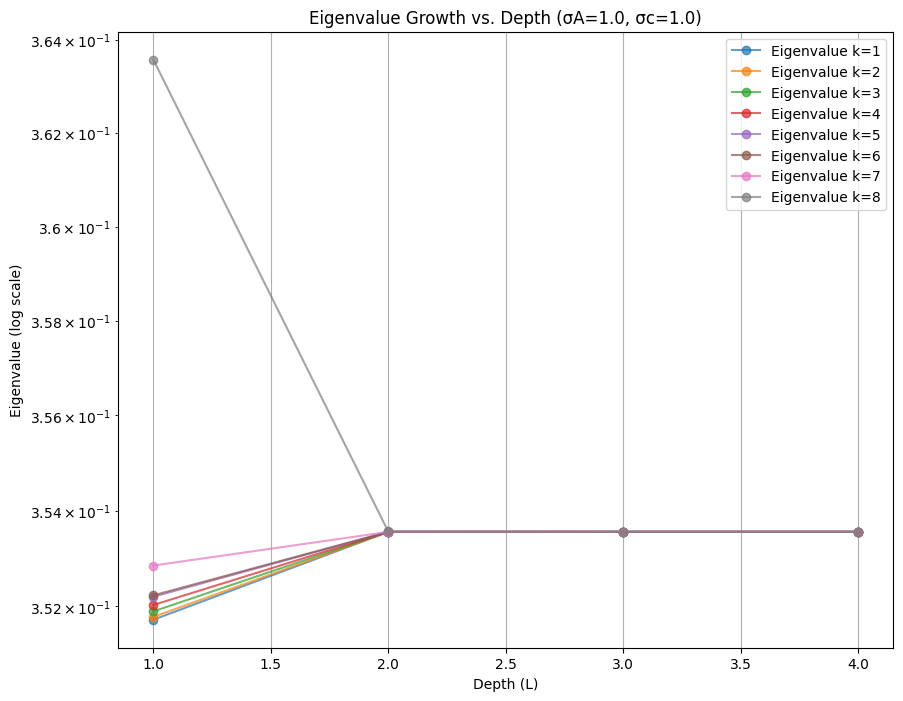

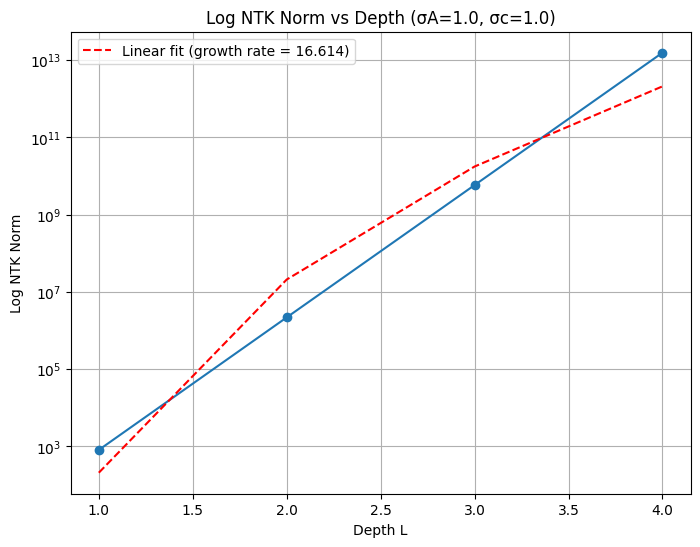

Testing σA values:  17%|█▋        | 1/6 [00:15<01:19, 15.84s/it]


Testing depth 1 for σA=1.1, σc=1.0


[[284.67456     1.0819443   1.4437355   1.1558375   1.033262    1.043844
    1.12112     1.2697473]
 [  1.0819443 284.67456     1.1530493   1.1330427   1.1658752   1.3606987
    1.1982068   1.0412302]
 [  1.4437355   1.1530493 284.67456     1.113746    1.0376416   1.0724771
    1.1273438   1.1953521]
 [  1.1558375   1.1330427   1.113746  284.67456     1.0800722   1.2051768
    1.1201645   1.1697636]
 [  1.033262    1.1658752   1.0376416   1.0800722 284.67456     1.2483004
    1.2719718   1.1005207]
 [  1.043844    1.3606987   1.0724771   1.2051768   1.2483004 284.67456
    1.3171742   1.0143291]
 [  1.12112     1.1982068   1.1273438   1.1201645   1.2719718   1.3171742
  284.67456     1.0473169]
 [  1.2697473   1.0412302   1.1953521   1.1697636   1.1005207   1.0143291
    1.0473169 284.67456  ]]
Testing depth 2 for σA=1.1, σc=1.0


[[9.2493588e+05 2.4289305e+00 2.9067678e+00 2.5265241e+00 2.3646340e+00
  2.3786101e+00 2.4806714e+00 2.6769705e+00]
 [2.4289305e+00 9.2493588e+05 2.5228417e+00 2.4964180e+00 2.5397816e+00
  2.7970953e+00 2.5824831e+00 2.3751578e+00]
 [2.9067678e+00 2.5228417e+00 9.2493588e+05 2.4709320e+00 2.3704183e+00
  2.4164267e+00 2.4888914e+00 2.5787129e+00]
 [2.5265241e+00 2.4964180e+00 2.4709320e+00 9.2493588e+05 2.4264576e+00
  2.5916886e+00 2.4794095e+00 2.5449169e+00]
 [2.3646340e+00 2.5397816e+00 2.3704183e+00 2.4264576e+00 9.2493588e+05
  2.6486444e+00 2.6799085e+00 2.4534650e+00]
 [2.3786101e+00 2.7970953e+00 2.4164267e+00 2.5916886e+00 2.6486444e+00
  9.2493588e+05 2.7396097e+00 2.3396287e+00]
 [2.4806714e+00 2.5824831e+00 2.4888914e+00 2.4794095e+00 2.6799085e+00
  2.7396097e+00 9.2493588e+05 2.3831968e+00]
 [2.6769705e+00 2.3751578e+00 2.5787129e+00 2.5449169e+00 2.4534650e+00
  2.3396287e+00 2.3831968e+00 9.2493588e+05]]
Testing depth 3 for σA=1.1, σc=1.0


[[3.0142820e+09 4.2100210e+00 4.8415203e+00 4.3389983e+00 4.1250482e+00
  4.1435184e+00 4.2784004e+00 4.5378251e+00]
 [4.2100210e+00 3.0142820e+09 4.3341322e+00 4.2992105e+00 4.3565192e+00
  4.6965795e+00 4.4129524e+00 4.1389561e+00]
 [4.8415203e+00 4.3341322e+00 3.0142820e+09 4.2655292e+00 4.1326923e+00
  4.1934958e+00 4.2892637e+00 4.4079700e+00]
 [4.3389983e+00 4.2992105e+00 4.2655292e+00 3.0142820e+09 4.2067528e+00
  4.4251184e+00 4.2767324e+00 4.3633060e+00]
 [4.1250482e+00 4.3565192e+00 4.1326923e+00 4.2067528e+00 3.0142820e+09
  4.5003901e+00 4.5417080e+00 4.2424450e+00]
 [4.1435184e+00 4.6965795e+00 4.1934958e+00 4.4251184e+00 4.5003901e+00
  3.0142820e+09 4.6206074e+00 4.0920019e+00]
 [4.2784004e+00 4.4129524e+00 4.2892637e+00 4.2767324e+00 4.5417080e+00
  4.6206074e+00 3.0142820e+09 4.1495800e+00]
 [4.5378251e+00 4.1389561e+00 4.4079700e+00 4.3633060e+00 4.2424450e+00
  4.0920019e+00 4.1495800e+00 3.0142820e+09]]
Testing depth 4 for σA=1.1, σc=1.0


[[9.7082860e+12 6.5628834e+00 7.3973112e+00 6.7333069e+00 6.4506054e+00
  6.4750109e+00 6.6532364e+00 6.9960256e+00]
 [6.5628834e+00 9.7082860e+12 6.7268772e+00 6.6807337e+00 6.7564578e+00
  7.2057943e+00 6.8310256e+00 6.4689822e+00]
 [7.3973112e+00 6.7268772e+00 9.7082860e+12 6.6362290e+00 6.4607058e+00
  6.5410480e+00 6.6675906e+00 6.8244419e+00]
 [6.7333069e+00 6.6807337e+00 6.6362290e+00 9.7082860e+12 6.5585651e+00
  6.8471012e+00 6.6510324e+00 6.7654257e+00]
 [6.4506054e+00 6.7564578e+00 6.4607058e+00 6.5585651e+00 9.7082860e+12
  6.9465609e+00 7.0011559e+00 6.6057267e+00]
 [6.4750109e+00 7.2057943e+00 6.5410480e+00 6.8471012e+00 6.9465609e+00
  9.7082860e+12 7.1054091e+00 6.4069400e+00]
 [6.6532364e+00 6.8310256e+00 6.6675906e+00 6.6510324e+00 7.0011559e+00
  7.1054091e+00 9.7082860e+12 6.4830203e+00]
 [6.9960256e+00 6.4689822e+00 6.8244419e+00 6.7654257e+00 6.6057267e+00
  6.4069400e+00 6.4830203e+00 9.7082860e+12]]


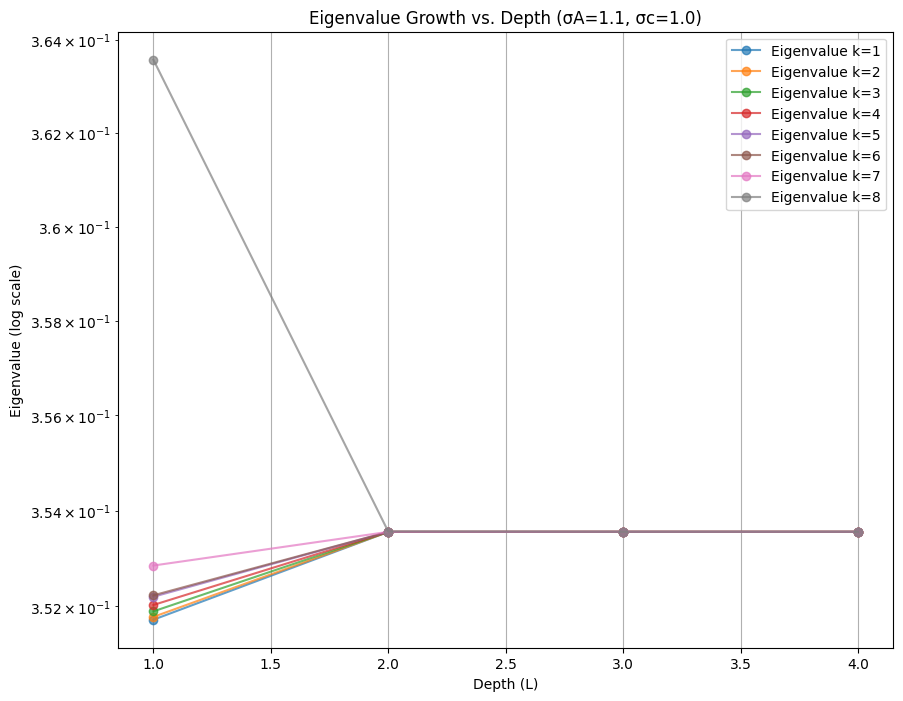

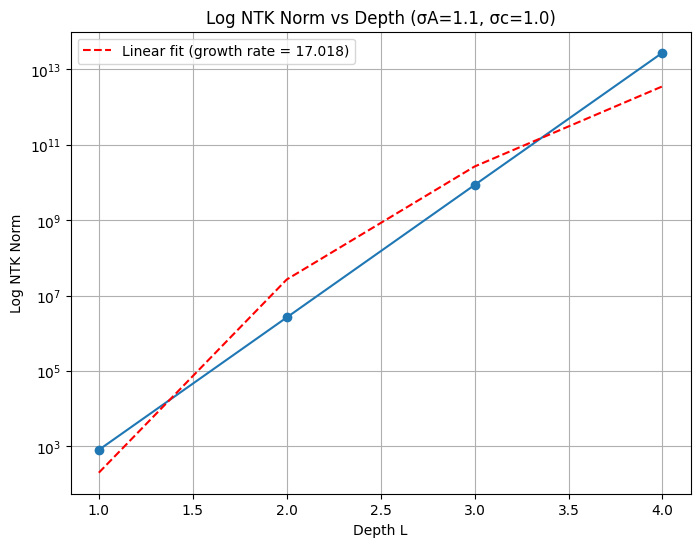

Testing σA values:  33%|███▎      | 2/6 [00:28<00:55, 13.97s/it]


Testing depth 1 for σA=1.2, σc=1.0


[[284.67456     1.0819443   1.4437355   1.1558375   1.033262    1.043844
    1.12112     1.2697473]
 [  1.0819443 284.67456     1.1530493   1.1330427   1.1658752   1.3606987
    1.1982068   1.0412302]
 [  1.4437355   1.1530493 284.67456     1.113746    1.0376416   1.0724771
    1.1273438   1.1953521]
 [  1.1558375   1.1330427   1.113746  284.67456     1.0800722   1.2051768
    1.1201645   1.1697636]
 [  1.033262    1.1658752   1.0376416   1.0800722 284.67456     1.2483004
    1.2719718   1.1005207]
 [  1.043844    1.3606987   1.0724771   1.2051768   1.2483004 284.67456
    1.3171742   1.0143291]
 [  1.12112     1.1982068   1.1273438   1.1201645   1.2719718   1.3171742
  284.67456     1.0473169]
 [  1.2697473   1.0412302   1.1953521   1.1697636   1.1005207   1.0143291
    1.0473169 284.67456  ]]
Testing depth 2 for σA=1.2, σc=1.0


[[1.0917082e+06 2.7024331e+00 3.2718287e+00 2.8187265e+00 2.6258166e+00
  2.6424701e+00 2.7640877e+00 2.9979997e+00]
 [2.7024331e+00 1.0917082e+06 2.8143387e+00 2.7828519e+00 2.8345237e+00
  3.1411412e+00 2.8854077e+00 2.6383569e+00]
 [3.2718287e+00 2.8143387e+00 1.0917082e+06 2.7524822e+00 2.6327090e+00
  2.6875329e+00 2.7738829e+00 2.8809152e+00]
 [2.8187265e+00 2.7828519e+00 2.7524822e+00 1.0917082e+06 2.6994863e+00
  2.8963773e+00 2.7625837e+00 2.8406432e+00]
 [2.6258166e+00 2.8345237e+00 2.6327090e+00 2.6994863e+00 1.0917082e+06
  2.9642458e+00 3.0015011e+00 2.7316685e+00]
 [2.6424701e+00 3.1411412e+00 2.6875329e+00 2.8963773e+00 2.9642458e+00
  1.0917082e+06 3.0726409e+00 2.5960197e+00]
 [2.7640877e+00 2.8854077e+00 2.7738829e+00 2.7625837e+00 3.0015011e+00
  3.0726409e+00 1.0917082e+06 2.6479361e+00]
 [2.9979997e+00 2.6383569e+00 2.8809152e+00 2.8406432e+00 2.7316685e+00
  2.5960197e+00 2.6479361e+00 1.0917082e+06]]
Testing depth 3 for σA=1.2, σc=1.0


[[4.3004902e+09 5.2497816e+00 6.1451492e+00 5.4326515e+00 5.1293030e+00
  5.1554904e+00 5.3467326e+00 5.7145562e+00]
 [5.2497816e+00 4.3004902e+09 5.4257517e+00 5.3762388e+00 5.4574924e+00
  5.9396448e+00 5.5375066e+00 5.1490226e+00]
 [6.1451492e+00 5.4257517e+00 4.3004902e+09 5.3284831e+00 5.1401410e+00
  5.2263513e+00 5.3621354e+00 5.5304422e+00]
 [5.4326515e+00 5.3762388e+00 5.3284831e+00 4.3004902e+09 5.2451477e+00
  5.5547562e+00 5.3443675e+00 5.4671149e+00]
 [5.1293030e+00 5.4574924e+00 5.1401410e+00 5.2451477e+00 4.3004902e+09
  5.6614785e+00 5.7200618e+00 5.2957535e+00]
 [5.1554904e+00 5.9396448e+00 5.2263513e+00 5.5547562e+00 5.6614785e+00
  4.3004902e+09 5.8319287e+00 5.0824475e+00]
 [5.3467326e+00 5.5375066e+00 5.3621354e+00 5.3443675e+00 5.7200618e+00
  5.8319287e+00 4.3004902e+09 5.1640854e+00]
 [5.7145562e+00 5.1490226e+00 5.5304422e+00 5.4671149e+00 5.2957535e+00
  5.0824475e+00 5.1640854e+00 4.3004902e+09]]
Testing depth 4 for σA=1.2, σc=1.0


[[1.6523728e+13 9.2516994e+00 1.0659044e+01 9.5391359e+00 9.0623302e+00
  9.1034918e+00 9.4040880e+00 9.9822359e+00]
 [9.2516994e+00 1.6523728e+13 9.5282907e+00 9.4504662e+00 9.5781803e+00
  1.0336031e+01 9.7039480e+00 9.0933256e+00]
 [1.0659044e+01 9.5282907e+00 1.6523728e+13 9.3754034e+00 9.0793657e+00
  9.2148714e+00 9.4282980e+00 9.6928434e+00]
 [9.5391359e+00 9.4504662e+00 9.3754034e+00 1.6523728e+13 9.2444162e+00
  9.7310610e+00 9.4003706e+00 9.5933056e+00]
 [9.0623302e+00 9.5781803e+00 9.0793657e+00 9.2444162e+00 1.6523728e+13
  9.8988075e+00 9.9908895e+00 9.3239584e+00]
 [9.1034918e+00 1.0336031e+01 9.2148714e+00 9.7310610e+00 9.8988075e+00
  1.6523728e+13 1.0166722e+01 8.9886827e+00]
 [9.4040880e+00 9.7039480e+00 9.4282980e+00 9.4003706e+00 9.9908895e+00
  1.0166722e+01 1.6523728e+13 9.1170015e+00]
 [9.9822359e+00 9.0933256e+00 9.6928434e+00 9.5933056e+00 9.3239584e+00
  8.9886827e+00 9.1170015e+00 1.6523728e+13]]


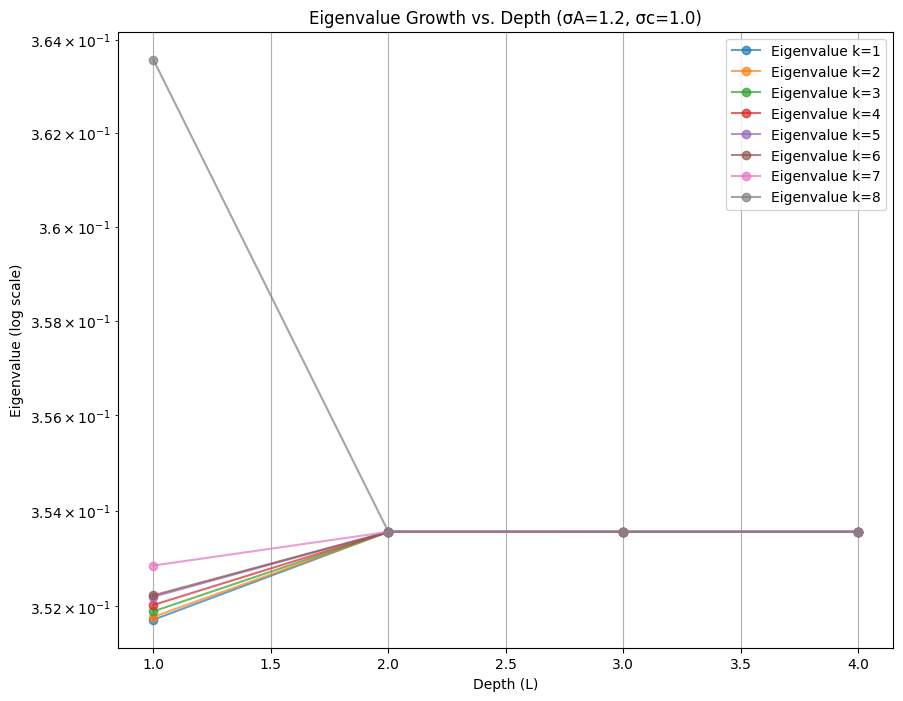

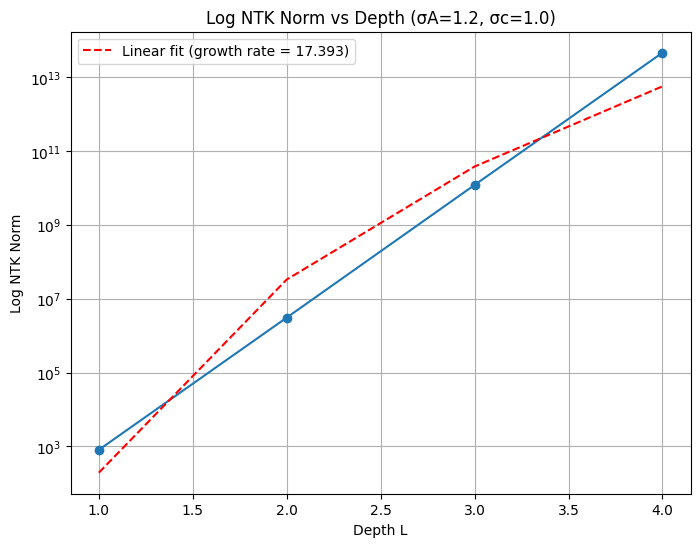

Testing σA values:  50%|█████     | 3/6 [00:38<00:36, 12.17s/it]


Testing depth 1 for σA=1.3, σc=1.0


[[284.67456     1.0819443   1.4437355   1.1558375   1.033262    1.043844
    1.12112     1.2697473]
 [  1.0819443 284.67456     1.1530493   1.1330427   1.1658752   1.3606987
    1.1982068   1.0412302]
 [  1.4437355   1.1530493 284.67456     1.113746    1.0376416   1.0724771
    1.1273438   1.1953521]
 [  1.1558375   1.1330427   1.113746  284.67456     1.0800722   1.2051768
    1.1201645   1.1697636]
 [  1.033262    1.1658752   1.0376416   1.0800722 284.67456     1.2483004
    1.2719718   1.1005207]
 [  1.043844    1.3606987   1.0724771   1.2051768   1.2483004 284.67456
    1.3171742   1.0143291]
 [  1.12112     1.1982068   1.1273438   1.1201645   1.2719718   1.3171742
  284.67456     1.0473169]
 [  1.2697473   1.0412302   1.1953521   1.1697636   1.1005207   1.0143291
    1.0473169 284.67456  ]]
Testing depth 2 for σA=1.3, σc=1.0


[[1.3047044e+06 2.9941206e+00 3.6609550e+00 3.1303151e+00 2.9043932e+00
  2.9238973e+00 3.0663264e+00 3.3402677e+00]
 [2.9941206e+00 1.3047044e+06 3.1251762e+00 3.0883014e+00 3.1488159e+00
  3.5079045e+00 3.2084084e+00 2.9190798e+00]
 [3.6609550e+00 3.1251762e+00 1.3047044e+06 3.0527351e+00 2.9124656e+00
  2.9766712e+00 3.0777974e+00 3.2031467e+00]
 [3.1303151e+00 3.0883014e+00 3.0527351e+00 1.3047044e+06 2.9906702e+00
  3.2212551e+00 3.0645649e+00 3.1559827e+00]
 [2.9043932e+00 3.1488159e+00 2.9124656e+00 2.9906702e+00 1.3047044e+06
  3.3007381e+00 3.3443677e+00 3.0283592e+00]
 [2.9238973e+00 3.5079045e+00 2.9766712e+00 3.2212551e+00 3.3007381e+00
  1.3047044e+06 3.4276824e+00 2.8694978e+00]
 [3.0663264e+00 3.2084084e+00 3.0777974e+00 3.0645649e+00 3.3443677e+00
  3.4276824e+00 1.3047044e+06 2.9302981e+00]
 [3.3402677e+00 2.9190798e+00 3.2031467e+00 3.1559827e+00 3.0283592e+00
  2.8694978e+00 2.9302981e+00 1.3047044e+06]]
Testing depth 3 for σA=1.3, σc=1.0


[[5.8221420e+09 6.5223913e+00 7.7523074e+00 6.7735896e+00 6.3568969e+00
  6.3928704e+00 6.6555681e+00 7.1608286e+00]
 [6.5223913e+00 5.8221420e+09 6.7641115e+00 6.6960993e+00 6.8077126e+00
  7.4700193e+00 6.9176259e+00 6.3839850e+00]
 [7.7523074e+00 6.7641115e+00 5.8221420e+09 6.6305003e+00 6.3717856e+00
  6.4902072e+00 6.6767254e+00 6.9079208e+00]
 [6.7735896e+00 6.6960993e+00 6.6305003e+00 5.8221420e+09 6.5160275e+00
  6.9413204e+00 6.6523194e+00 6.8209314e+00]
 [6.3568969e+00 6.8077126e+00 6.3717856e+00 6.5160275e+00 5.8221420e+09
  7.0879197e+00 7.1683908e+00 6.5855412e+00]
 [6.3928704e+00 7.4700193e+00 6.4902072e+00 6.9413204e+00 7.0879197e+00
  5.8221420e+09 7.3220572e+00 6.2925358e+00]
 [6.6555681e+00 6.9176259e+00 6.6767254e+00 6.6523194e+00 7.1683908e+00
  7.3220572e+00 5.8221420e+09 6.4046764e+00]
 [7.1608286e+00 6.3839850e+00 6.9079208e+00 6.8209314e+00 6.5855412e+00
  6.2925358e+00 6.4046764e+00 5.8221420e+09]]
Testing depth 4 for σA=1.3, σc=1.0


[[2.66680370e+13 1.30315981e+01 1.53003693e+01 1.34949722e+01
  1.27263184e+01 1.27926769e+01 1.32772636e+01 1.42092953e+01]
 [1.30315981e+01 2.66680370e+13 1.34774885e+01 1.33520298e+01
  1.35579176e+01 1.47796450e+01 1.37606697e+01 1.27762861e+01]
 [1.53003693e+01 1.34774885e+01 2.66680370e+13 1.32310219e+01
  1.27537832e+01 1.29722300e+01 1.33162918e+01 1.37427673e+01]
 [1.34949722e+01 1.33520298e+01 1.32310219e+01 2.66680370e+13
  1.30198593e+01 1.38043785e+01 1.32712708e+01 1.35823021e+01]
 [1.27263184e+01 1.35579176e+01 1.27537832e+01 1.30198593e+01
  2.66680370e+13 1.40748034e+01 1.42232447e+01 1.31480885e+01]
 [1.27926769e+01 1.47796450e+01 1.29722300e+01 1.38043785e+01
  1.40748034e+01 2.66680370e+13 1.45067062e+01 1.26075945e+01]
 [1.32772636e+01 1.37606697e+01 1.33162918e+01 1.32712708e+01
  1.42232447e+01 1.45067062e+01 2.66680370e+13 1.28144550e+01]
 [1.42092953e+01 1.27762861e+01 1.37427673e+01 1.35823021e+01
  1.31480885e+01 1.26075945e+01 1.28144550e+01 2.66680370e+13]]

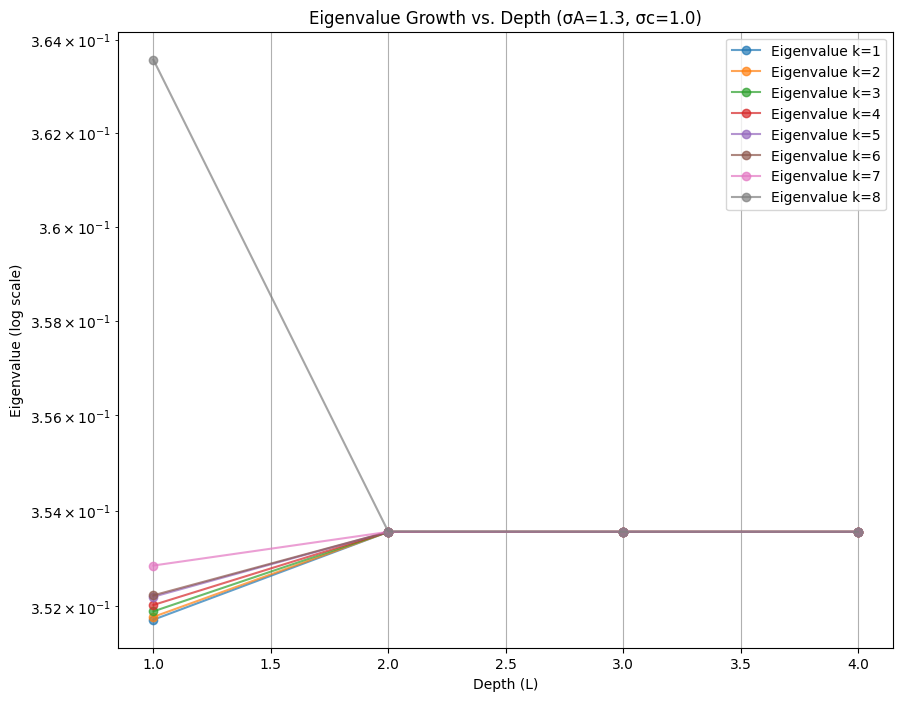

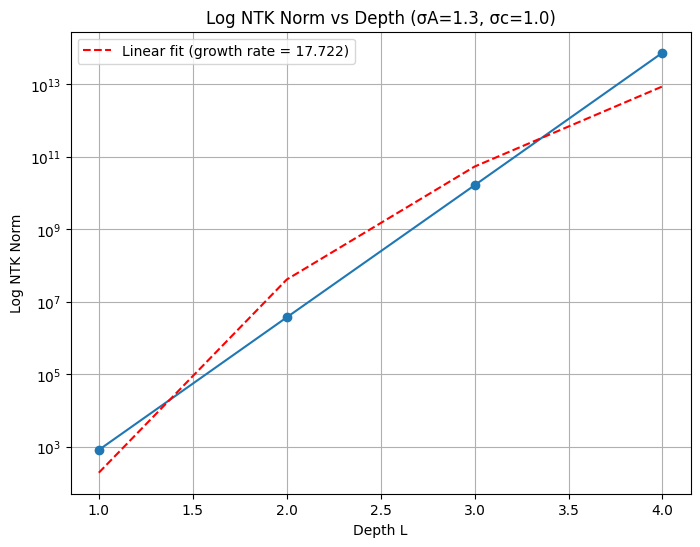

Testing σA values:  67%|██████▋   | 4/6 [00:48<00:22, 11.40s/it]


Testing depth 1 for σA=1.4, σc=1.0


[[284.67456     1.0819443   1.4437355   1.1558375   1.033262    1.043844
    1.12112     1.2697473]
 [  1.0819443 284.67456     1.1530493   1.1330427   1.1658752   1.3606987
    1.1982068   1.0412302]
 [  1.4437355   1.1530493 284.67456     1.113746    1.0376416   1.0724771
    1.1273438   1.1953521]
 [  1.1558375   1.1330427   1.113746  284.67456     1.0800722   1.2051768
    1.1201645   1.1697636]
 [  1.033262    1.1658752   1.0376416   1.0800722 284.67456     1.2483004
    1.2719718   1.1005207]
 [  1.043844    1.3606987   1.0724771   1.2051768   1.2483004 284.67456
    1.3171742   1.0143291]
 [  1.12112     1.1982068   1.1273438   1.1201645   1.2719718   1.3171742
  284.67456     1.0473169]
 [  1.2697473   1.0412302   1.1953521   1.1697636   1.1005207   1.0143291
    1.0473169 284.67456  ]]
Testing depth 2 for σA=1.4, σc=1.0


[[1.4613624e+06 3.3151541e+00 4.0893526e+00 3.4732838e+00 3.2109818e+00
  3.2336254e+00 3.3989835e+00 3.7170351e+00]
 [3.3151541e+00 1.4613624e+06 3.4673176e+00 3.4244964e+00 3.4947631e+00
  3.9116602e+00 3.5639482e+00 3.2280321e+00]
 [4.0893526e+00 3.4673176e+00 1.4613624e+06 3.3832047e+00 3.2203534e+00
  3.2948956e+00 3.4123018e+00 3.5578396e+00]
 [3.4732838e+00 3.4244964e+00 3.3832047e+00 1.4613624e+06 3.3111479e+00
  3.5788627e+00 3.3969393e+00 3.5030837e+00]
 [3.2109818e+00 3.4947631e+00 3.2203534e+00 3.3111479e+00 1.4613624e+06
  3.6711419e+00 3.7217953e+00 3.3549047e+00]
 [3.2336254e+00 3.9116602e+00 3.2948956e+00 3.5788627e+00 3.6711419e+00
  1.4613624e+06 3.8185229e+00 3.1704683e+00]
 [3.3989835e+00 3.5639482e+00 3.4123018e+00 3.3969393e+00 3.7217953e+00
  3.8185229e+00 1.4613624e+06 3.2410569e+00]
 [3.7170351e+00 3.2280321e+00 3.5578396e+00 3.5030837e+00 3.3549047e+00
  3.1704683e+00 3.2410569e+00 1.4613624e+06]]
Testing depth 3 for σA=1.4, σc=1.0


[[7.5020390e+09 8.0953503e+00 9.7523499e+00 8.4337921e+00 7.8723927e+00
  7.9208560e+00 8.2747688e+00 8.9554863e+00]
 [8.0953503e+00 7.5020390e+09 8.4210224e+00 8.3293724e+00 8.4797630e+00
  9.3720388e+00 8.6278381e+00 7.9088850e+00]
 [9.7523499e+00 8.4210224e+00 7.5020390e+09 8.2409973e+00 7.8924503e+00
  8.0519915e+00 8.3032732e+00 8.6147652e+00]
 [8.4337921e+00 8.3293724e+00 8.2409973e+00 7.5020390e+09 8.0867758e+00
  8.6597595e+00 8.2703934e+00 8.4975719e+00]
 [7.8723927e+00 8.4797630e+00 7.8924503e+00 8.0867758e+00 7.5020390e+09
  8.8572626e+00 8.9656754e+00 8.1804276e+00]
 [7.9208560e+00 9.3720388e+00 8.0519915e+00 8.6597595e+00 8.8572626e+00
  7.5020390e+09 9.1726990e+00 7.7856822e+00]
 [8.2747688e+00 8.6278381e+00 8.3032732e+00 8.2703934e+00 8.9656754e+00
  9.1726990e+00 7.5020390e+09 7.9367614e+00]
 [8.9554863e+00 7.9088850e+00 8.6147652e+00 8.4975719e+00 8.1804276e+00
  7.7856822e+00 7.9367614e+00 7.5020390e+09]]
Testing depth 4 for σA=1.4, σc=1.0


[[3.8859082e+13 1.8327204e+01 2.1873829e+01 1.9051601e+01 1.7849989e+01
  1.7953718e+01 1.8711229e+01 2.0168230e+01]
 [1.8327204e+01 3.8859082e+13 1.9024269e+01 1.8828102e+01 1.9149998e+01
  2.1059814e+01 1.9466936e+01 1.7928097e+01]
 [2.1873829e+01 1.9024269e+01 3.8859082e+13 1.8638947e+01 1.7892920e+01
  1.8234400e+01 1.8772240e+01 1.9438955e+01]
 [1.9051601e+01 1.8828102e+01 1.8638947e+01 3.8859082e+13 1.8308851e+01
  1.9535259e+01 1.8701864e+01 1.9188116e+01]
 [1.7849989e+01 1.9149998e+01 1.7892920e+01 1.8308851e+01 3.8859082e+13
  1.9957993e+01 2.0190039e+01 1.8509302e+01]
 [1.7953718e+01 2.1059814e+01 1.8234400e+01 1.9535259e+01 1.9957993e+01
  3.8859082e+13 2.0633150e+01 1.7664394e+01]
 [1.8711229e+01 1.9466936e+01 1.8772240e+01 1.8701864e+01 2.0190039e+01
  2.0633150e+01 3.8859082e+13 1.7987762e+01]
 [2.0168230e+01 1.7928097e+01 1.9438955e+01 1.9188116e+01 1.8509302e+01
  1.7664394e+01 1.7987762e+01 3.8859082e+13]]


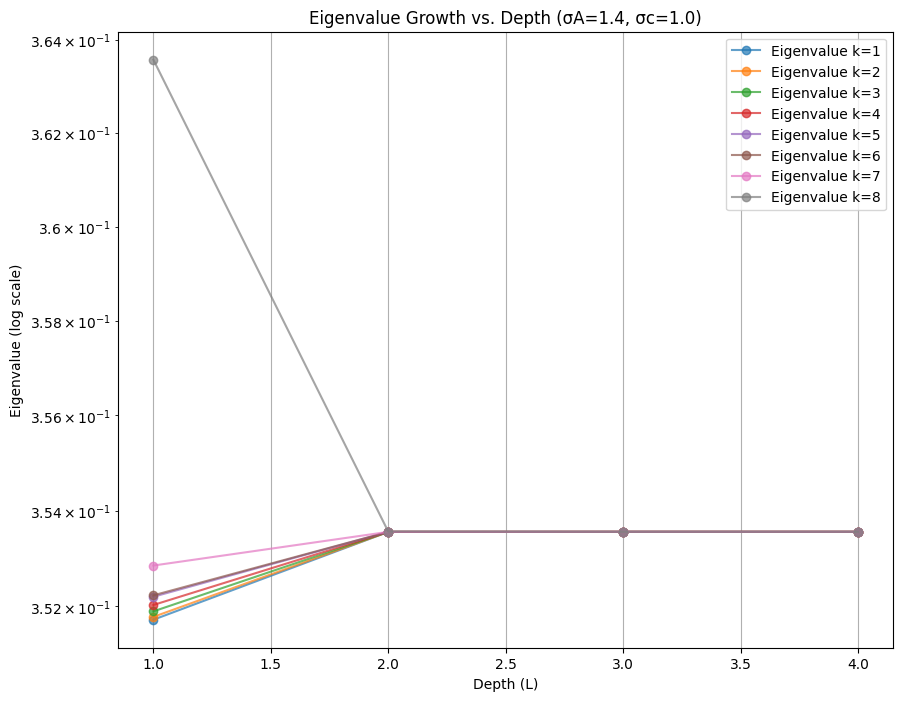

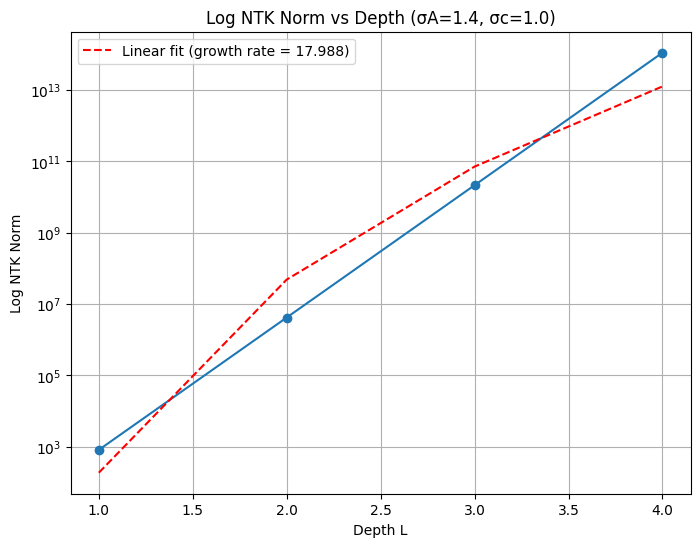

Testing σA values:  83%|████████▎ | 5/6 [01:07<00:13, 13.96s/it]


Testing depth 1 for σA=1.4142135381698608, σc=1.0


[[284.67456     1.0819443   1.4437355   1.1558375   1.033262    1.043844
    1.12112     1.2697473]
 [  1.0819443 284.67456     1.1530493   1.1330427   1.1658752   1.3606987
    1.1982068   1.0412302]
 [  1.4437355   1.1530493 284.67456     1.113746    1.0376416   1.0724771
    1.1273438   1.1953521]
 [  1.1558375   1.1330427   1.113746  284.67456     1.0800722   1.2051768
    1.1201645   1.1697636]
 [  1.033262    1.1658752   1.0376416   1.0800722 284.67456     1.2483004
    1.2719718   1.1005207]
 [  1.043844    1.3606987   1.0724771   1.2051768   1.2483004 284.67456
    1.3171742   1.0143291]
 [  1.12112     1.1982068   1.1273438   1.1201645   1.2719718   1.3171742
  284.67456     1.0473169]
 [  1.2697473   1.0412302   1.1953521   1.1697636   1.1005207   1.0143291
    1.0473169 284.67456  ]]
Testing depth 2 for σA=1.4142135381698608, σc=1.0


[[1.5084125e+06 3.3621683e+00 4.1520734e+00 3.5234990e+00 3.2558804e+00
  3.2789841e+00 3.4477000e+00 3.7721996e+00]
 [3.3621683e+00 1.5084125e+06 3.5174117e+00 3.4737308e+00 3.5454144e+00
  3.9707756e+00 3.6160040e+00 3.2732775e+00]
 [4.1520734e+00 3.5174117e+00 1.5084125e+06 3.4316008e+00 3.2654424e+00
  3.3414986e+00 3.4612885e+00 3.6097715e+00]
 [3.5234990e+00 3.4737308e+00 3.4316008e+00 1.5084125e+06 3.3580806e+00
  3.6312218e+00 3.4456139e+00 3.5539038e+00]
 [3.2558804e+00 3.5454144e+00 3.2654424e+00 3.3580806e+00 1.5084125e+06
  3.7253742e+00 3.7770565e+00 3.4027262e+00]
 [3.2789841e+00 3.9707756e+00 3.3414986e+00 3.6312218e+00 3.7253742e+00
  1.5084125e+06 3.8757479e+00 3.2145443e+00]
 [3.4477000e+00 3.6160040e+00 3.4612885e+00 3.4456139e+00 3.7770565e+00
  3.8757479e+00 1.5084125e+06 3.2865663e+00]
 [3.7721996e+00 3.2732775e+00 3.6097715e+00 3.5539038e+00 3.4027262e+00
  3.2145443e+00 3.2865663e+00 1.5084125e+06]]
Testing depth 3 for σA=1.4142135381698608, σc=1.0


[[8.2168340e+09 8.3287601e+00 1.0050574e+01 8.6804256e+00 8.0970774e+00
  8.1474380e+00 8.5152006e+00 9.2225361e+00]
 [8.3287601e+00 8.2168340e+09 8.6671562e+00 8.5719414e+00 8.7281952e+00
  9.6553860e+00 8.8820648e+00 8.1349993e+00]
 [1.0050574e+01 8.6671562e+00 8.2168340e+09 8.4801083e+00 8.1179199e+00
  8.2837057e+00 8.5448208e+00 8.8684788e+00]
 [8.6804256e+00 8.5719414e+00 8.4801083e+00 8.2168340e+09 8.3198509e+00
  8.9152355e+00 8.5106525e+00 8.7467003e+00]
 [8.0970774e+00 8.7281952e+00 8.1179199e+00 8.3198509e+00 8.2168340e+09
  9.1204672e+00 9.2331228e+00 8.4171677e+00]
 [8.1474380e+00 9.6553860e+00 8.2837057e+00 8.9152355e+00 9.1204672e+00
  8.2168340e+09 9.4482470e+00 8.0069742e+00]
 [8.5152006e+00 8.8820648e+00 8.5448208e+00 8.5106525e+00 9.2331228e+00
  9.4482470e+00 8.2168340e+09 8.1639652e+00]
 [9.2225361e+00 8.1349993e+00 8.8684788e+00 8.7467003e+00 8.4171677e+00
  8.0069742e+00 8.1639652e+00 8.2168340e+09]]
Testing depth 4 for σA=1.4142135381698608, σc=1.0


[[4.3553837e+13 1.9186659e+01 2.2946407e+01 1.9954554e+01 1.8680756e+01
  1.8790724e+01 1.9593769e+01 2.1138306e+01]
 [1.9186659e+01 4.3553837e+13 1.9925579e+01 1.9717669e+01 2.0058865e+01
  2.2083475e+01 2.0394854e+01 1.8763563e+01]
 [2.2946407e+01 1.9925579e+01 4.3553837e+13 1.9517141e+01 1.8726269e+01
  1.9088278e+01 1.9658447e+01 2.0365187e+01]
 [1.9954554e+01 1.9717669e+01 1.9517141e+01 4.3553837e+13 1.9167204e+01
  2.0467285e+01 1.9583838e+01 2.0099272e+01]
 [1.8680756e+01 2.0058865e+01 1.8726269e+01 1.9167204e+01 4.3553837e+13
  2.0915428e+01 2.1161423e+01 1.9379705e+01]
 [1.8790724e+01 2.2083475e+01 1.9088278e+01 2.0467285e+01 2.0915428e+01
  4.3553837e+13 2.1631166e+01 1.8484007e+01]
 [1.9593769e+01 2.0394854e+01 1.9658447e+01 1.9583838e+01 2.1161423e+01
  2.1631166e+01 4.3553837e+13 1.8826813e+01]
 [2.1138306e+01 1.8763563e+01 2.0365187e+01 2.0099272e+01 1.9379705e+01
  1.8484007e+01 1.8826813e+01 4.3553837e+13]]


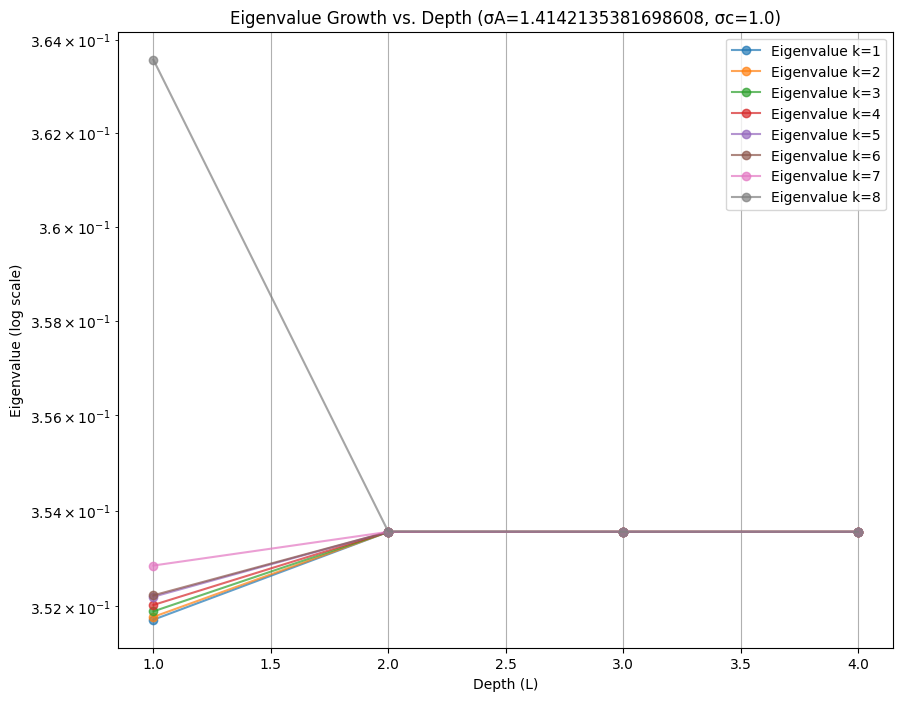

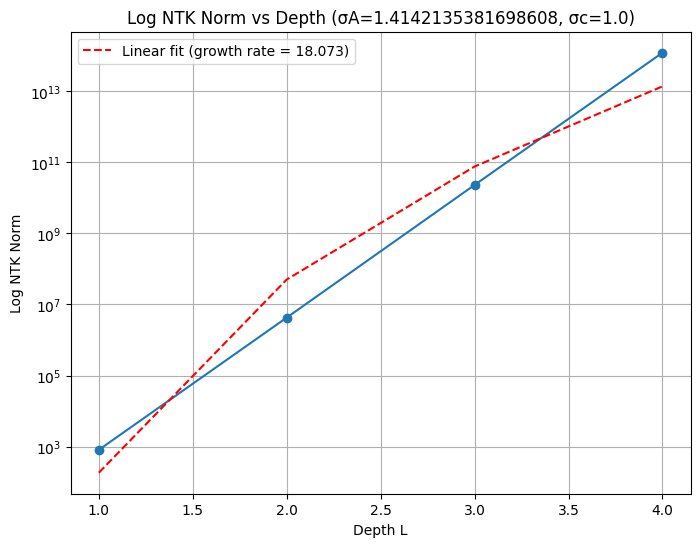

Testing σA values: 100%|██████████| 6/6 [01:18<00:00, 13.05s/it]


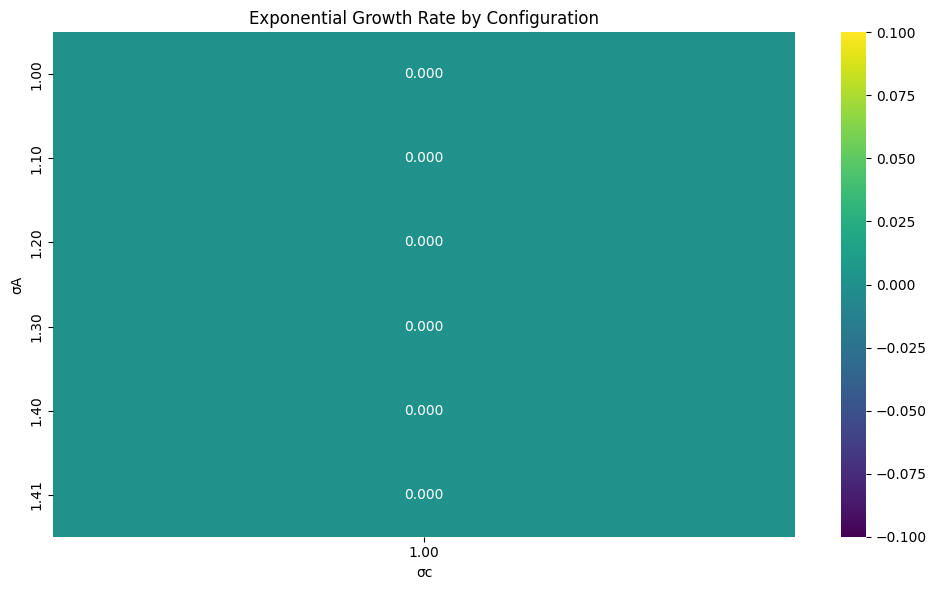

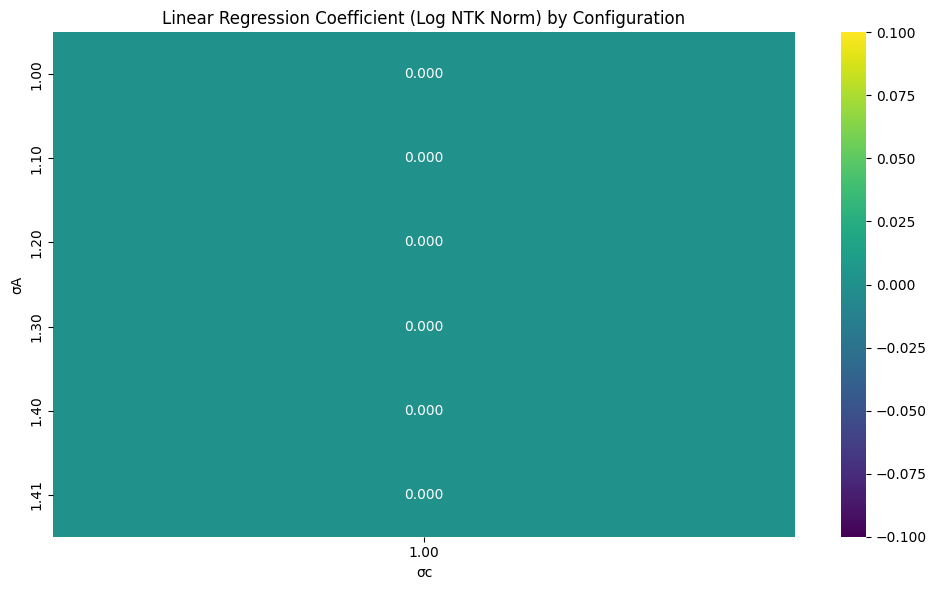

In [2]:
# we set up base parameters
key = random.PRNGKey(42)
input_dim = 5  # we fix input dimension to 10
rank = 10  # we fix rank to 10
beta = 1.0  # we fix random bias scaling
n_samples = 8  # we fix sample size
depths = list(range(1, 5))  # we test depths 1 to 10

# we test different sigma_A and sigma_c combinations
sigma_As = [1.0,1.1,1.2,1.3,1.4,jnp.sqrt(2)]
sigma_cs = [1.0]

# we generate test data
X = random.normal(key, (n_samples, input_dim))
X = X / jnp.linalg.norm(X, axis=1, keepdims=True)  # we normalize to unit sphere
# we store growth rates for heatmap
growth_rates = jnp.zeros((len(sigma_As), len(sigma_cs)))
linreg_coeffs = jnp.zeros((len(sigma_As), len(sigma_cs)))
stable_configs = []
for i, sigma_A in tqdm(enumerate(sigma_As), desc="Testing σA values", total=len(sigma_As)):
    for j, sigma_c in tqdm(enumerate(sigma_cs), desc=f"Testing σc values for σA={sigma_A}", leave=False, total=len(sigma_cs)):
        max_eigenval_ratio = 0
        try:
            eigenvals_by_depth = []
            l2_norms_by_depth = []  # we track L2 norms of differences
            ntk_norms_by_depth = []  # we track NTK norms
            prev_ntk = None  # we store previous NTK for diff computation
            
            # we create basis vectors for I and J decomposition
            I = jnp.eye(n_samples)  # identity matrix

            J = (jnp.ones((n_samples, n_samples)) - I )   # normalized all-ones matrix
            J = J / jnp.linalg.norm(J)
            I = I / jnp.linalg.norm(I)
        
            # we store projections for each depth
            I_projs = []
            J_projs = []
            all_eigenvals_for_plot = [] # we store all eigenvalues for plotting their growth
            
            for L in tqdm(depths, desc=f"Testing depths for σA={sigma_A}, σc={sigma_c}", leave=False):
                print(f"Testing depth {L} for σA={sigma_A}, σc={sigma_c}")
                d_hidden = [rank] * (L-1)
                kernels = compute_ntk_nngp_recursive(X, L, d_hidden, sigma_A, sigma_c, beta, activation_fn=sin, activation_dot_fn=sin_dot)
                ntk_final = kernels['ntk'][L]
                # we ensure symmetry by averaging with transpose
                ntk_final = (ntk_final + ntk_final.T) / 2
                
                
                ntk_norm = jnp.linalg.norm(ntk_final, ord='fro')
                ntk_norms_by_depth.append(ntk_norm)
                
                I_proj_coeff = jnp.abs(jnp.sum(ntk_final * I))  # normalized projection coefficient for I
                J_proj_coeff = jnp.abs(jnp.sum(ntk_final * J))  # normalized projection coefficient for J    
                I_projs.append(I_proj_coeff)
                J_projs.append(J_proj_coeff)
            
                eigenvals = eigvalsh(ntk_final)
                all_eigenvals_for_plot.append(eigenvals/ntk_norm) # we collect eigenvalues for the plot
                l2_norms_by_depth.append(jnp.linalg.norm(ntk_final - I*I_proj_coeff - J*J_proj_coeff, ord='fro'))
                
                
                if jnp.any(jnp.isnan(eigenvals)): #check for NaN values early
                    raise ValueError("NaN eigenvalues detected")
                    
                eigenvals_by_depth.append(jnp.max(eigenvals))
                print(ntk_final)

            
            plt.figure(figsize=(10, 8)) #we plot the growth of each eigenvalue vs depth
            all_eigenvals_for_plot = jnp.array(all_eigenvals_for_plot)
            for k in range(n_samples):
                plt.plot(depths, all_eigenvals_for_plot[:, k], marker='o', linestyle='-', alpha=0.7, label=f'Eigenvalue k={k+1}')
            plt.yscale('log')
            plt.title(f'Eigenvalue Growth vs. Depth (σA={sigma_A}, σc={sigma_c})')
            plt.xlabel('Depth (L)')
            plt.ylabel('Eigenvalue (log scale)')
            plt.legend()
            plt.grid(True)
            plt.show()

            
            # we plot NTK norms in log space
            plt.figure(figsize=(8, 6))
            norms = jnp.array(ntk_norms_by_depth)  # we convert list to array before taking log
            plt.plot(depths, norms, marker='o')
            
            # we perform linear regression on log norms
            depths_array = jnp.array(depths, dtype=jnp.float32)  # we convert depths to float array
            coeffs = jnp.polyfit(jnp.log(depths_array), jnp.log(norms), deg=1)
            growth_rate = coeffs[0]  # slope is the growth rate
            
            plt.plot(depths_array, jnp.exp(coeffs[0] * jnp.log(depths_array) + coeffs[1]), 'r--', 
                    label=f'Linear fit (growth rate = {growth_rate:.3f})')
            plt.title(f'Log NTK Norm vs Depth (σA={sigma_A}, σc={sigma_c})')
            plt.xlabel('Depth L')
            plt.ylabel('Log NTK Norm')
            plt.legend()
            plt.yscale('log')
            plt.grid(True)
            plt.show()
            
        except Exception as e:
            print(f"Error at σA={sigma_A}, σc={sigma_c}: {str(e)}")  # we log the specific error
            growth_rates = growth_rates.at[i, j].set(jnp.nan)
            continue
        
        
        
# we handle the case where all configs failed
if jnp.all(jnp.isnan(growth_rates)):
    print("Warning: All configurations resulted in NaN values")
    plt.figure(figsize=(10, 6))
    plt.text(0.5, 0.5, 'No valid data to display\nAll configurations unstable', 
             horizontalalignment='center', verticalalignment='center')
    plt.title('Growth Rate Analysis Failed')
    plt.tight_layout()
    plt.show()
else:
    # we plot exponential growth rate heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(growth_rates, 
                xticklabels=[f"{x:.2f}" for x in sigma_cs],
                yticklabels=[f"{x:.2f}" for x in sigma_As],
                cmap='viridis',
                annot=True, fmt='.3f')
    plt.title('Exponential Growth Rate by Configuration')
    plt.xlabel('σc')
    plt.ylabel('σA')
    plt.tight_layout()
    plt.show()

    # we plot linear regression coefficient heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(linreg_coeffs, 
                xticklabels=[f"{x:.2f}" for x in sigma_cs],
                yticklabels=[f"{x:.2f}" for x in sigma_As],
                cmap='viridis',
                annot=True, fmt='.3f')
    plt.title('Linear Regression Coefficient (Log NTK Norm) by Configuration')
    plt.xlabel('σc')
    plt.ylabel('σA')
    plt.tight_layout()
    plt.show()

In [3]:
if len(stable_configs) > 0:
    # we choose the most stable configuration (lowest max ratio)
    stable_configs.sort(key=lambda x: x[2])
    best_sigma_A, best_sigma_c, _, best_growth = stable_configs[0]
    print(f"\nBest configuration: sigma_A={best_sigma_A}, sigma_c={best_sigma_c}, exp_growth={best_growth:.3f}")

    # we plot spectrum for the stable configuration
    plt.figure(figsize=(10, 6))
    data_types = ['Sphere', 'Gaussian', 'Cube']
    data_generators = [
        lambda k, n, d: random.normal(k, (n, d)) / jnp.linalg.norm(random.normal(k, (n, d)), axis=1, keepdims=True),
        lambda k, n, d: random.normal(k, (n, d)),
        lambda k, n, d: 2 * random.uniform(k, (n, d)) - 1
    ]

    for idx, (data_type, generator) in enumerate(tqdm(list(zip(data_types, data_generators)), desc="Testing data distributions")):
        eigenvalues_by_depth = []
        X = generator(key, n_samples, input_dim)
        
        for L in tqdm(depths, desc=f"Computing depths for {data_type}", leave=False):
            d_hidden = [rank] * (L-1)
            kernels = compute_ntk_nngp_recursive(X, L, d_hidden, best_sigma_A, best_sigma_c, beta)
            ntk_final = kernels['ntk'][L]
            # we ensure symmetry by averaging with transpose
            ntk_final = (ntk_final + ntk_final.T) / 2
            eigenvals = eigvalsh(ntk_final)
            eigenvalues_by_depth.append(eigenvals)
        
        eigenvalues_by_depth = jnp.array(eigenvalues_by_depth)
        for i in range(n_samples):
            plt.plot(depths, eigenvalues_by_depth[:, i],
                    alpha=0.5, label=f'{data_type} n={i+1}' if i==0 else None)

    plt.title(f'Stable NTK Eigenspectrum (σA={best_sigma_A:.2f}, σc={best_sigma_c:.2f})')
    plt.xlabel('Network Depth (L)')
    plt.ylabel('Eigenvalues')
    plt.yscale('log')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No stable configurations found")

No stable configurations found


## Observations:

1. Found stable configuration with σA={best_sigma_A:.2f}, σc={best_sigma_c:.2f}, exp_growth={best_growth:.3f}
2. This configuration shows controlled growth of eigenvalues with depth
3. Different data distributions still show distinct but stable spectral patterns
4. Heatmap reveals patterns in exponential growth rates across configurations